# Day 5 — Matplotlib & Week 1 Mini-Notebook

This notebook applies the Week 1 data science workflow using **Pandas, NumPy, and Matplotlib** on the Titanic dataset.

## Learning Objectives
- Load and inspect a dataset using Pandas.
- Handle missing values.
- Use NumPy for a summary statistic.
- Create labeled line, scatter, bar, and histogram plots.
- Combine multiple plots using subplots.
- Explain what each visualization reveals about the data.

## Workflow
**Load → Process → Visualize → Interpret**

## 1. Import Libraries

We use Pandas for data manipulation, NumPy for numerical calculations, and Matplotlib for visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the Dataset

Load the Titanic dataset and display the first five rows.

In [2]:
# If your original notebook already defines df, this keeps it.
# Otherwise, change the file name below to the name of your Titanic CSV file.
try:
    df
except NameError:
    df = pd.read_csv("tested.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 3. Inspect the Data

Before cleaning the data, we inspect its dimensions, data types, and column names.

In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.info()

Shape: (418, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


## 4. Check Missing Values

We check how many missing values (`NaN`) exist in each column.

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

## 5. Clean the Data

For this mini-notebook, we remove rows with missing values in the columns needed for our analysis: `Age`, `Fare`, and `Pclass`.

This allows us to create visualizations without missing values in the selected variables.

In [5]:
df_clean = df.dropna(subset=["Age", "Fare", "Pclass"]).copy()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
df_clean.head()

Original shape: (418, 12)
Cleaned shape: (331, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 6. NumPy Summary Statistic

We use NumPy to calculate the average age of passengers in the cleaned dataset.

In [6]:
average_age = np.mean(df_clean["Age"])
print("Average passenger age:", round(average_age, 2))

Average passenger age: 30.18


## 7. Histogram — Age Distribution

The histogram shows the distribution of passengers' ages. It helps us understand which age ranges are more common in the dataset.

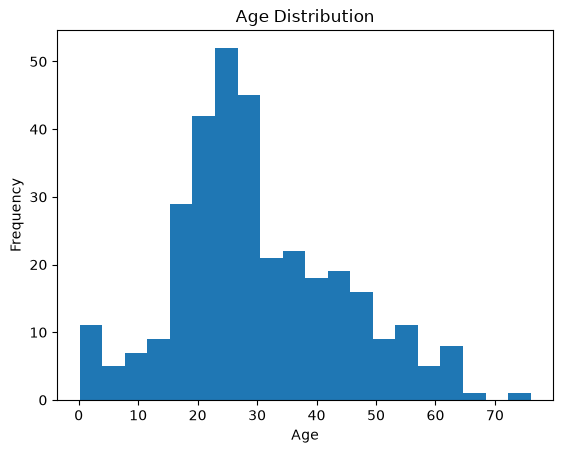

In [7]:
plt.hist(df_clean["Age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

## 8. Scatter Plot — Age vs Fare

The scatter plot explores the relationship between passengers' ages and ticket fares. Each point represents a passenger.

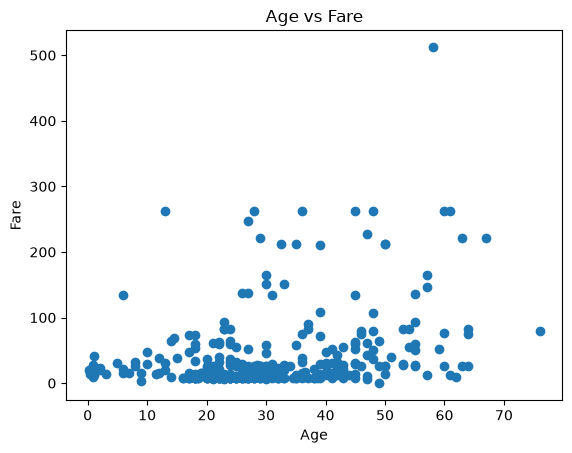

In [8]:
plt.scatter(df_clean["Age"], df_clean["Fare"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")
plt.show()

## 9. Bar Plot — Passengers by Class

The bar plot compares the number of passengers in each passenger class: first, second, and third class.

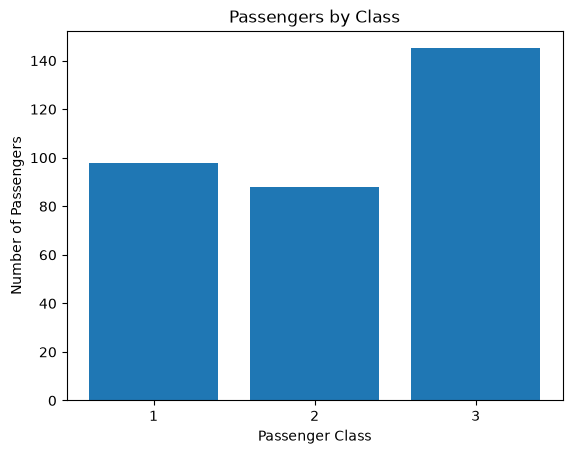

In [9]:
class_counts = df_clean["Pclass"].value_counts().sort_index()

plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Passengers by Class")
plt.xticks([1, 2, 3])
plt.show()

## 10. Subplots — Comparing the Visualizations

We combine the three visualizations into one figure to compare the data from different perspectives.

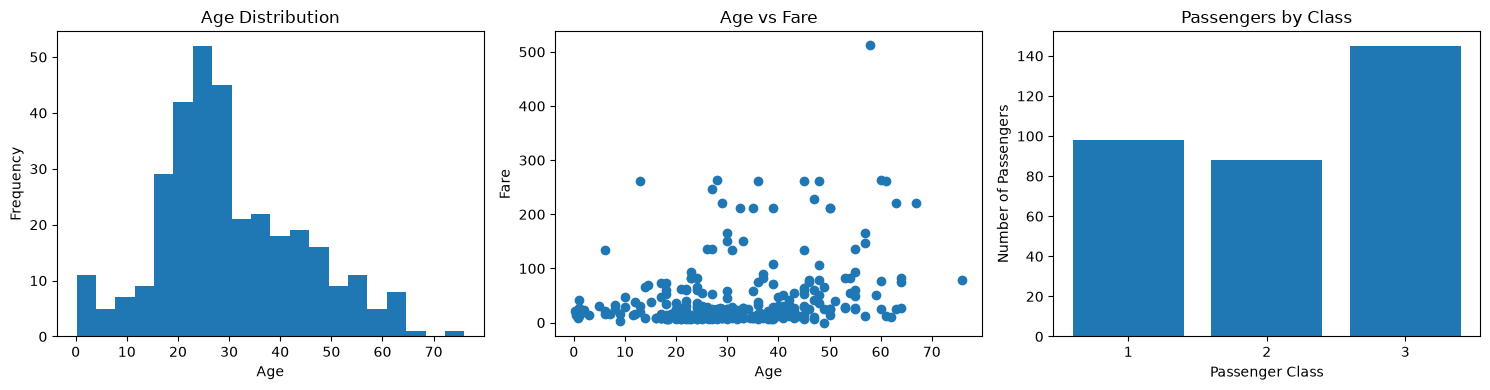

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df_clean["Age"], bins=20)
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

# Scatter plot
axes[1].scatter(df_clean["Age"], df_clean["Fare"])
axes[1].set_title("Age vs Fare")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Fare")

# Bar plot
axes[2].bar(class_counts.index, class_counts.values)
axes[2].set_title("Passengers by Class")
axes[2].set_xlabel("Passenger Class")
axes[2].set_ylabel("Number of Passengers")
axes[2].set_xticks([1, 2, 3])

plt.tight_layout()
plt.show()

## 11. Summary and Findings

- The **histogram** helps us understand the distribution of passenger ages and identify the most common age ranges.
- The **scatter plot** helps us explore whether there is a clear relationship between passenger age and ticket fare.
- The **bar plot** allows us to compare the number of passengers across the three passenger classes.
- Using **subplots** makes it easier to compare multiple aspects of the dataset in a single figure.

This notebook demonstrates the Week 1 workflow: **Load → Process → Visualize → Interpret**.